# Figure 3 - Proteostasis rewiring
Mathieu Bourdenx - UCL/UKDRI - 2026

In [30]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import pearsonr, zscore

import sys
sys.path.append('..')

from src.pathway_score import calc_pathway_score

# Housekeeping

In [2]:
raw_data_path = '../data/raw_data'
processed_data_path = '../data/processed_data'
results_path = '../results'

figure_path = '../figures/figure3'
os.makedirs(figure_path, exist_ok=True)

In [3]:
# Group colors
group_colors = {'pos': '#FEC200', 
         'neg': '#0C6F9F',}

In [4]:
# FDR threshold
fdr_thresh = 0.05

# Load data

In [5]:
sc_ad = sc.read_h5ad(os.path.join(processed_data_path, 'sc_processed.h5ad'))

In [6]:
correlation_results = pd.read_csv(os.path.join(results_path, 'SuppTable3_sc_correlation_tau.csv'))

# Proteasome subunits

In [7]:
all_proteasome = [i for i in sc_ad.var['GeneName'] if 'PSM' in i]

In [8]:
proteasome_corr_val = correlation_results[correlation_results['GeneName'].isin(all_proteasome)]

In [10]:
for i in proteasome_corr_val.index:
    name = proteasome_corr_val.loc[i, 'GeneName']
    proteasome_corr_val.loc[i, 'type'] = name[3]
    proteasome_corr_val.loc[i, 'subunit'] = int(name[4:])

# Fix subunit dtype
proteasome_corr_val['subunit'] = proteasome_corr_val['subunit'].astype(int)

# Now map the type to an integer
proteasome_corr_val['type_int'] = proteasome_corr_val['type'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5})
proteasome_corr_val['type_int'] = proteasome_corr_val['type_int'].astype(int)

/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_34213/2928014736.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proteasome_corr_val.loc[i, 'type'] = name[3]
/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_34213/2928014736.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  proteasome_corr_val.loc[i, 'subunit'] = int(name[4:])
/var/folders/3_/3d2084dj4kdgndylxrd58s500000gn/T/ipykernel_34213/2928014736.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice f

In [11]:
# Fill a matrix with the correlation values
prot_corr_mat = np.full((6, proteasome_corr_val['subunit'].max()+1), np.nan)
for i in proteasome_corr_val.index:
    prot_corr_mat[proteasome_corr_val.loc[i, 'type_int'], proteasome_corr_val.loc[i, 'subunit']] = proteasome_corr_val.loc[i, 'corr_stat']

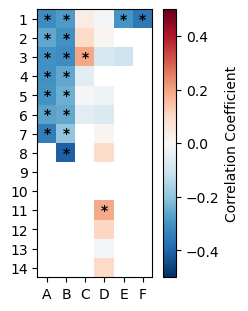

In [12]:
# Plot the matrix and add a star where significant correlations are found

plt.figure(figsize=(3,3), constrained_layout=True)
plt.imshow(prot_corr_mat.T, cmap='RdBu_r', vmin=-.5, vmax=.5)
plt.ylim(14.5, 0.5)

for i in proteasome_corr_val.index:
    if proteasome_corr_val.loc[i, 'corr_adj.pval'] < fdr_thresh:
        plt.text(proteasome_corr_val.loc[i, 'type_int'], proteasome_corr_val.loc[i, 'subunit'], '*', ha='center', va='center', color='k', fontdict={'weight': 'bold'})

plt.xticks([0,1,2,3,4,5], ['A', 'B', 'C', 'D', 'E', 'F'])
plt.yticks(range(1, 15, 1))
plt.colorbar(label='Correlation Coefficient')
plt.savefig(os.path.join(figure_path, 'Fig3a_proteasome_corr_mat.png'), dpi=300)
plt.show()

# Proteasome score

In [33]:
proteasome_subunits = ['PSMA1', 'PSMA2', 'PSMA3', 'PSMA4', 'PSMA5', 'PSMA6', 'PSMA7', 'PSMB1', 'PSMB2', 'PSMB3', 'PSMB4', 'PSMB5', 'PSMB6', 'PSMB7', 'PSMB8', 'PSME1', 'PSMF1']
prot20s_genes = ['PSMA7', 'PSMB1','PSMA1', 'PSMA2', 'PSMA3', 'PSMA4', 'PSMB8', 'PSMA5', 'PSMB4', 'PSMB6', 'PSMB5', 'PSMB3', 'PSMB2', 'PSMA6', 'PSMB7']
lyso_acid = ['ATP6V1G1','ATP6V1G2','ATP6V1B2','ATP6V1C1','ATP6V1E1','ATP6V1A','ATP6V0D1','ATP6V1F','ATP6V0A1','ATP6V1H','ATP6V1D']

In [23]:
# Calculate proteasome score
proteasome_score = calc_pathway_score(sc_ad, proteasome_subunits)

# Calculate Pearson correlation between MAPT and proteasome score   
pearsonr(sc_ad[:, 'MAPT'].X.ravel(), proteasome_score)

PearsonRResult(statistic=np.float64(-0.338214931158806), pvalue=np.float64(2.198392056705541e-06))

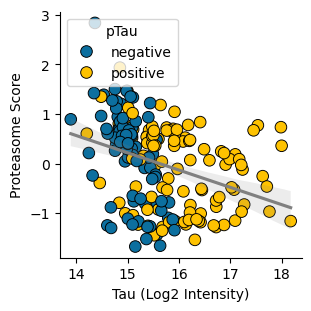

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3), constrained_layout=True)
sns.scatterplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= proteasome_score, hue=list(sc_ad.obs['TauStatus'].values), hue_order=['negative', 'positive'],
                palette=[group_colors['neg'], group_colors['pos']], s=70, edgecolor='k', ax=ax)
sns.regplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= proteasome_score, scatter=False, color='gray', ax=ax)
sns.despine()
ax.legend(title='pTau', loc='upper left')
ax.set_ylabel('Proteasome Score')
ax.set_xlabel('Tau (Log2 Intensity)')

plt.savefig(os.path.join(figure_path, 'Fig3b_tau_proteasome_corr.png'), dpi=300)
plt.show()

# Subunit correlations

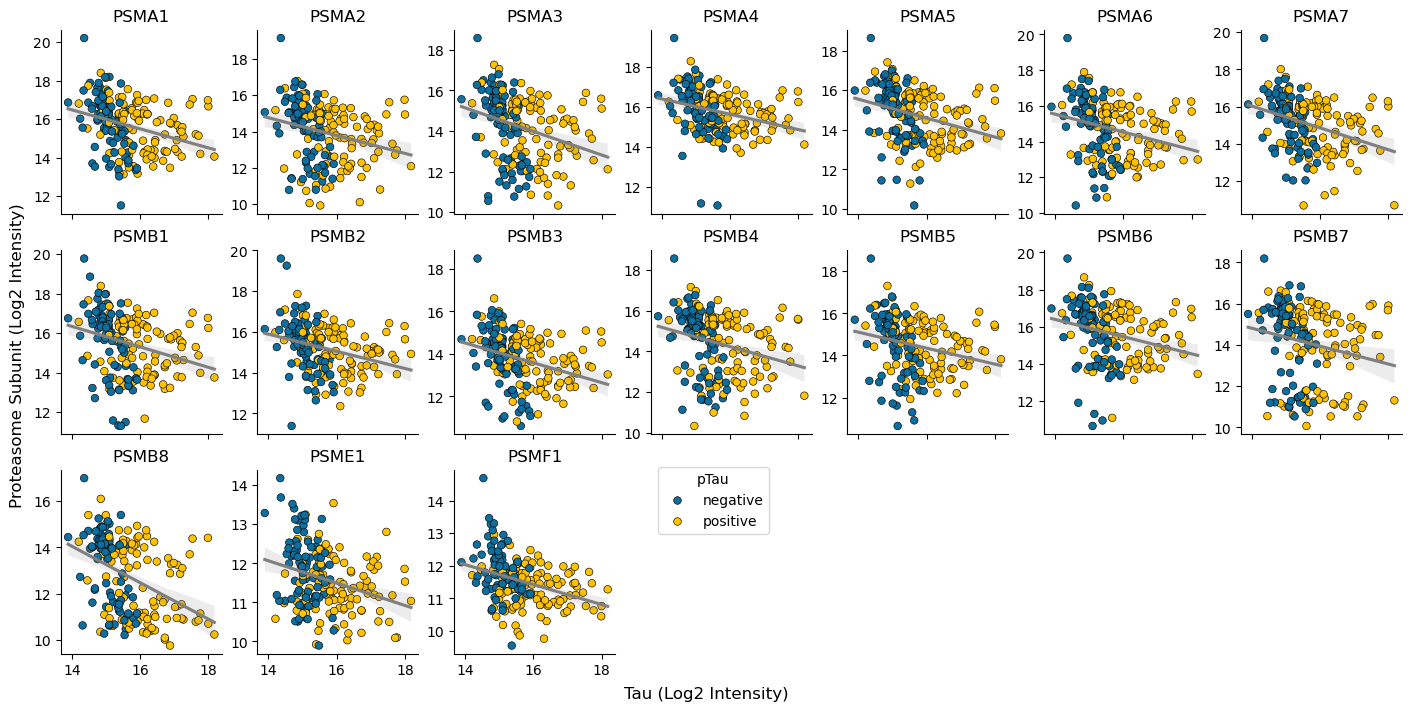

In [24]:
fig, ax = plt.subplots(nrows=3, ncols=7, figsize=(14,7), constrained_layout=True, sharex=True, sharey=False)

for i,p in enumerate(proteasome_subunits):
    sns.scatterplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= sc_ad[:, p].X.ravel(), hue=list(sc_ad.obs['TauStatus'].values), hue_order=['negative', 'positive'],
                palette=[group_colors['neg'], group_colors['pos']], s=30, edgecolor='k', ax=ax[i//7, i%7])
    sns.regplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= sc_ad[:, p].X.ravel(), scatter=False, color='gray', ax=ax[i//7, i%7])
    sns.despine()
    ax[i//7, i%7].set_title(p)
    ax[i//7, i%7].legend_.remove()
    # ax[i//7, i%7].set_yticklabels([])
    # ax[i//7, i%7].set_xlabel('MAPT (Log2 Intensity)')

# Single legend (collect handles from one axis or all)
handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title='pTau', loc='upper right', bbox_to_anchor=(0.55, 0.35))

fig.supxlabel('Tau (Log2 Intensity)')
fig.supylabel('Proteasome Subunit (Log2 Intensity)')

fig.delaxes(ax[2, 3])
fig.delaxes(ax[2, 4])
fig.delaxes(ax[2, 5])
fig.delaxes(ax[2, 6])

plt.savefig(os.path.join(figure_path, 'FigS6_proteasome_subunits.png'), dpi=300)

# UbK48 correlation

In [25]:
# Set outlier to nan
sc_ad.obs.loc[sc_ad.obs['intensity_ub'] == sc_ad.obs['intensity_ub'].max(), 'intensity_ub'] = np.nan

In [26]:
# Calculate Pearson correlation between MAPT and K48Ub
no_nan = sc_ad.obs['intensity_ub'].notna()
pearsonr(sc_ad[:, 'MAPT'].X.ravel()[no_nan], sc_ad.obs['intensity_ub'][no_nan])

PearsonRResult(statistic=np.float64(0.4369489883459892), pvalue=np.float64(5.429790653591524e-08))

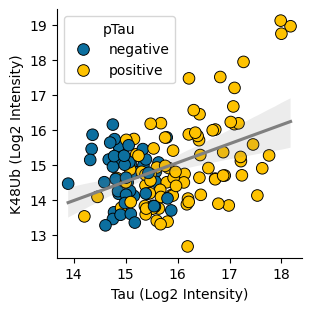

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3), constrained_layout=True)
sns.scatterplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= sc_ad.obs['intensity_ub'], hue=list(sc_ad.obs['TauStatus'].values), hue_order=['negative', 'positive'],
                palette=[group_colors['neg'], group_colors['pos']], s=70, edgecolor='k', ax=ax)
sns.regplot(x=sc_ad[:, 'MAPT'].X.ravel(), y= sc_ad.obs['intensity_ub'], scatter=False, color='gray', ax=ax)
sns.despine()
ax.legend(title='pTau', loc='upper left')
ax.set_ylabel('K48Ub (Log2 Intensity)')
ax.set_xlabel('Tau (Log2 Intensity)')

plt.savefig(os.path.join(figure_path, 'Fig3c_tau_ub.png'), dpi=300)
plt.show()

# Immunofluorescence for K48

In [44]:
# Load data
k48 = pd.read_excel(os.path.join(raw_data_path, 'AT8_K48_raw_data_excel.xlsx'))

# Fix image dtype
k48['Image'] = k48['Image'].astype('str')

In [45]:
for i in k48.index:
    patient_id = k48.loc[i, 'Image'].split('Processed_')[1].split('_NeuN')[0]
    k48.loc[i, 'patient_id'] = patient_id

In [46]:
# Group by patient and classification
grouped_classes = k48.groupby(by=['patient_id', 'Classification'])['Image'].count()
grouped_classes = pd.DataFrame(grouped_classes)
grouped_classes.reset_index(inplace=True)

In [47]:
# Get ratio of AT8+:K48+ images
at8pos = list()

selected_classes = grouped_classes[grouped_classes['Classification'].isin(['AT8+: K48-', 'AT8+: K48+'])]
for i in selected_classes['patient_id'].unique():

    p_data = selected_classes[selected_classes['patient_id'] == i]
    sum_im = p_data['Image'].sum()
    ratio = p_data[p_data['Classification'] == 'AT8+: K48+']['Image'] / sum_im

    res = {}
    res['p_id'] = i
    res['ratio_at8+'] = ratio.values[0]

    at8pos.append(res)

In [48]:
# Get ratio of AT8-:K48+ images
at8neg = list()

selected_classes = grouped_classes[grouped_classes['Classification'].isin(['AT8-: K48-', 'AT8-: K48+'])]
for i in selected_classes['patient_id'].unique():

    p_data = selected_classes[selected_classes['patient_id'] == i]
    sum_im = p_data['Image'].sum()

    if p_data.shape[0] == 1:
        ratio = 0
    else:
        ratio = p_data[p_data['Classification'] == 'AT8-: K48+']['Image'] / sum_im
        ratio = ratio.values[0]

    res = {}
    res['p_id'] = i
    res['ratio_at8+'] = ratio

    at8neg.append(res)

In [49]:
at8pos = pd.DataFrame(at8pos)
at8pos['class'] = 'AT8+'
at8neg = pd.DataFrame(at8neg)
at8neg['class'] = 'AT8-'

In [50]:
res_ratio = pd.concat([at8neg, at8pos])

/Users/mathieu/mambaforge/envs/sc_analysis/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 60.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


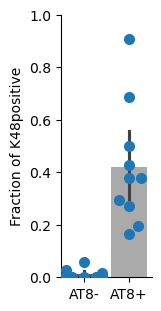

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(1.5,3), constrained_layout=True)

sns.barplot(res_ratio, x='class', y='ratio_at8+', hue='class', ax=ax, palette='gray')
sns.swarmplot(res_ratio, x='class', y='ratio_at8+', ax=ax, size=8)
sns.despine()
ax.set_ylim((0,1))
ax.set_ylabel('Fraction of K48positive')
ax.set_xlabel('')

plt.savefig(os.path.join(figure_path, 'Fig3f_K48_classification.png'), dpi=300)
plt.show()

In [43]:
bi_pos = k48[k48['Classification'] == 'AT8+: K48+']

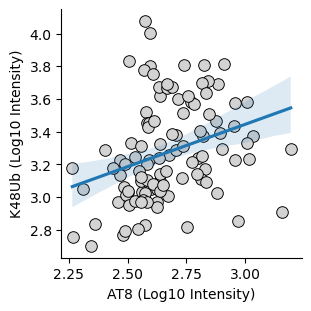

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3), constrained_layout=True)

sns.scatterplot(x=np.log10(bi_pos['Nucleus: AT8 mean']), y=np.log10(bi_pos['Nucleus: K48 mean']), s=70, edgecolor='k', color='lightgray')
sns.regplot(x=np.log10(bi_pos['Nucleus: AT8 mean']), y=np.log10(bi_pos['Nucleus: K48 mean']), ax=ax, scatter=False)
sns.despine()

ax.set_ylabel('K48Ub (Log10 Intensity)')
ax.set_xlabel('AT8 (Log10 Intensity)')

plt.savefig(os.path.join(figure_path, 'Fig3g_K48Intensity.png'), dpi=300)
plt.show()

In [58]:
pearsonr(np.log10(bi_pos['Nucleus: AT8 mean']), np.log10(bi_pos['Nucleus: K48 mean']))

PearsonRResult(statistic=np.float64(0.30961071300418147), pvalue=np.float64(0.0010526913512290718))

# Trend plots

In [34]:
sc_ad.obs['intensity_ub_z'] = zscore(sc_ad.obs['intensity_ub'], nan_policy='omit')
sc_ad.obs['proteasome_score'] = proteasome_score
sc_ad.obs['prot20s_score'] = calc_pathway_score(sc_ad, prot20s_genes)
sc_ad.obs['lyso_acid_score'] = calc_pathway_score(sc_ad, lyso_acid)


In [35]:
# bin protein_x and average protein_y within each bin
bins = pd.cut(sc_ad[:, 'MAPT'].X.ravel(), bins=5)  # or specify edges: bins=[0, 1, 2, 3]
ub_trend = sc_ad.obs.groupby(bins, observed=True)['intensity_ub_z'].mean()
ub_std = sc_ad.obs.groupby(bins, observed=True)['intensity_ub_z'].sem()

proteasome_trend = sc_ad.obs.groupby(bins, observed=True)['proteasome_score'].mean()
proteasome_std = sc_ad.obs.groupby(bins, observed=True)['proteasome_score'].sem()

# 20S trend
prot20s_trend = sc_ad.obs.groupby(bins, observed=True)['prot20s_score'].mean()
prot20s_std = sc_ad.obs.groupby(bins, observed=True)['prot20s_score'].sem()

# Lyso acid trend
lyso_acid_trend = sc_ad.obs.groupby(bins, observed=True)['lyso_acid_score'].mean()
lyso_acid_std = sc_ad.obs.groupby(bins, observed=True)['lyso_acid_score'].sem()


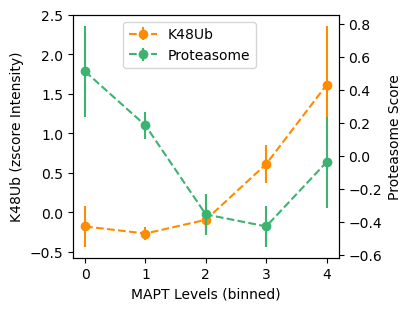

In [36]:
fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)

ax.errorbar(x=range(len(ub_trend.values)), y=ub_trend.values, yerr=ub_std.values, fmt='o--', color='darkorange', label='K48Ub')
ax.set_xticks(range(len(ub_trend.values)))

ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis
ax2.errorbar(x=range(len(proteasome_trend.values)), y=proteasome_trend.values, yerr=proteasome_std.values, fmt='o--', color='mediumseagreen', label='Proteasome')

fig.legend(loc=(.3, .78))

ax.set_xlabel('MAPT Levels (binned)')
ax.set_ylabel('K48Ub (zscore Intensity)')
ax2.set_ylabel('Proteasome Score')

fig.savefig(os.path.join(figure_path, 'Fig3h_tau_ub_protasome_score.png'), dpi=300)
plt.show()

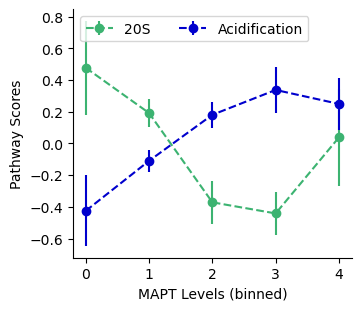

In [37]:
fig, ax = plt.subplots(figsize=(3.5,3), constrained_layout=True)

ax.errorbar(x=range(len(prot20s_trend.values)), y=prot20s_trend.values, yerr=prot20s_std.values, fmt='o--', color='mediumseagreen', label='20S')
ax.errorbar(x=range(len(lyso_acid_trend.values)), y=lyso_acid_trend.values, yerr=lyso_acid_std.values, fmt='o--', color='mediumblue', label='Acidification')

ax.legend(loc='upper left', ncol=3)
ax.set_xticks(range(len(prot20s_trend.values)))
ax.set_xlabel('MAPT Levels (binned)')
ax.set_ylabel('Pathway Scores')
sns.despine()
plt.savefig(os.path.join(figure_path, 'Fig3k_lyso_20s_scores.png'), dpi=300)
plt.show()

# V-ATPase subunits heatmap

In [18]:
vatpase = [i for i in sc_ad.var['GeneName'] if 'ATP6V' in i]
vatpase_corr = correlation_results[(correlation_results['GeneName'].isin(vatpase))].copy()
vatpase_corr.reset_index(inplace=True, drop=True)
vatpase_corr.sort_values(by='GeneName', ascending=True, inplace=True)
vatpase_corr.reset_index(inplace=True, drop=True)

In [19]:
vatpase_corr_mat = np.full((1, vatpase_corr.index.max()+1), np.nan)
for i in vatpase_corr.index:
    vatpase_corr_mat[0, i] = vatpase_corr.loc[i, 'corr_stat']

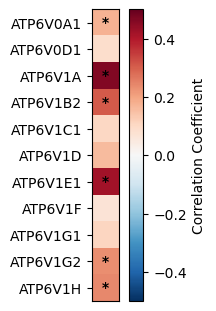

In [21]:
plt.figure(figsize=(3,3), constrained_layout=True)
plt.imshow(vatpase_corr_mat.T, cmap='RdBu_r', vmin=-.5, vmax=.5)
plt.yticks(range(vatpase_corr.index.max()+1), vatpase_corr['GeneName'])
plt.xticks([])
plt.colorbar(label='Correlation Coefficient')

for i in vatpase_corr.index:
    if vatpase_corr.loc[i, 'corr_adj.pval'] < fdr_thresh:
        plt.text(0, i, '*', ha='center', va='center', color='k', fontdict={'weight': 'bold'})

plt.savefig(os.path.join(figure_path, 'Fig3i_vatpase_corr_mat.png'), dpi=300)
plt.show()      


# Acidification score

In [39]:
# Calculate Pearson correlation between MAPT and acidification score
pearsonr(sc_ad[:, 'MAPT'].X.ravel(), sc_ad.obs['lyso_acid_score'])

PearsonRResult(statistic=np.float64(0.31409043319190155), pvalue=np.float64(1.1998176194328485e-05))

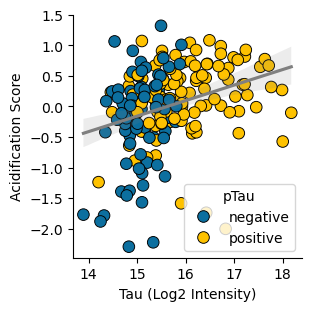

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3,3), constrained_layout=True)

sns.scatterplot(x=sc_ad[:, 'MAPT'].X.ravel(), y=sc_ad.obs['lyso_acid_score'], hue=list(sc_ad.obs['TauStatus'].values), hue_order=['negative', 'positive'],
                palette=[group_colors['neg'], group_colors['pos']], s=70, edgecolor='k', ax=ax)
sns.regplot(x=sc_ad[:, 'MAPT'].X.ravel(), y=sc_ad.obs['lyso_acid_score'], scatter=False, color='gray', ax=ax)
sns.despine()
ax.legend(title='pTau', loc='lower right')
ax.set_ylabel('Acidification Score')
ax.set_xlabel('Tau (Log2 Intensity)')

plt.savefig(os.path.join(figure_path, 'Fig3j_tau_acidification_score.png'), dpi=300)
plt.show()